# Analysis of The Movies dataset

## Executive Summary
This project analyzes a large movie dataset to understand what makes a film successful and how movie performance has changed over time. It looks at both financial outcomes and audience response, combining variables such as budget, revenue, profit, ROI and popularity.

The overall objective is to identify which movies perform best financially, which movies were the most popular, and how movie patterns change over time in terms of their finances and their popularity.

### Main Findings
The main findings are:
- Budget is strongly related to revenue, but not strongly related to profit. This suggests that spending more on a movie can increase earnings, yet it does not necessarily translate into higher profitability.
- Popularity is closely linked to audience engagement, as popularity and vote count show a strong positive relationship.
- Average movie ratings are only weakly associated with financial performance, meaning a film can be highly profitable without having an exceptionally high rating.
- The data is highly skewed: a small number of very successful films dominate revenue and profit, while most movies are clustered toward the lower end of the distribution.

## 1. Objective

The analysis aims to answer the following questions:
1. Which are the most financially successful movies?
2. Which are the most popular movies and genres? 
3. How has movie performances and preferences shifted over time? 


## 2. Setup

In [1]:
# let's import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style="whitegrid")

## 3. Dataset overview 
The dataset contains information on films from 1960 to 2015. It has 21 variables and 10,866 observations. 
The variables consists of a mix of numeric and string data types.
Initial inspection also shows that several variables contain missing values, such as, `director`, `production_companies` and `genre`.

In [2]:
movies = pd.read_csv("movies.csv")

movies.head(3)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08


In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [4]:
movies.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [5]:
movies.shape # this dataset has 21 columns

(10866, 21)

In [6]:
movies.columns

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview',
       'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='object')

In [7]:
movies.isnull().sum() # this dataset has 9 columns with missing values

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

## 4. Data Cleaning and Preparation 

### 4.1 Irrelevant variables 
There are some irrelevant variables in the dataset that we do not need for our analysis. 

In [8]:
# let's drop the columns that we don't need for our analysis

columns_to_drop = [
    'id', 'imdb_id', 'cast', 'homepage', 'tagline', 'keywords',
    'overview', 'runtime', 'budget_adj', 'revenue_adj', 'release_date'
]

movies.drop(columns=columns_to_drop, inplace=True)
movies.head(3)

,popularity,budget,revenue,original_title,director,genres,production_companies,vote_count,vote_average,release_year
0,32.985763,150000000,1513528810,Jurassic World,Colin Trevorrow,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015
1,28.419936,150000000,378436354,Mad Max: Fury Road,George Miller,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015
2,13.112507,110000000,295238201,Insurgent,Robert Schwentke,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,2015


### 4.2 Missing Values 
Rows with missing values in the `director` and `genres` columns were removed because only a small proportion of values were missing. In contrast, the `production_companies` column contained many missing values, so these were replaced with "Unknown". 

In [9]:
movies.isnull().sum() # we have missing values in the 'director', 'genres' and 'production companies' columns

popularity                 0
budget                     0
revenue                    0
original_title             0
director                  44
genres                    23
production_companies    1030
vote_count                 0
vote_average               0
release_year               0
dtype: int64

In [10]:
movies.dropna(inplace = True, subset =(['director', 'genres'])) # let's drop the rows with missing values in the 'director' and 'genres' columns
movies.isnull().sum()

popularity                0
budget                    0
revenue                   0
original_title            0
director                  0
genres                    0
production_companies    994
vote_count                0
vote_average              0
release_year              0
dtype: int64

In [11]:
movies['production_companies'] = movies['production_companies'].fillna('Unknown') # fill the missing values in the 'production companies' column with 'Unknown'
movies.head(3)

,popularity,budget,revenue,original_title,director,genres,production_companies,vote_count,vote_average,release_year
0,32.985763,150000000,1513528810,Jurassic World,Colin Trevorrow,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015
1,28.419936,150000000,378436354,Mad Max: Fury Road,George Miller,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015
2,13.112507,110000000,295238201,Insurgent,Robert Schwentke,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,2015


### 4.3 Duplicates 

In [12]:
movies.duplicated().sum() # let's check for duplicate rows in the dataset

np.int64(1)

In [13]:
duplicated_rows = movies[movies.duplicated()]
duplicated_rows

,popularity,budget,revenue,original_title,director,genres,production_companies,vote_count,vote_average,release_year
2090,0.59643,30000000,967000,TEKKEN,Dwight H. Little,Crime|Drama|Action|Thriller|Science Fiction,Namco|Light Song Films,110,5.0,2010


In [14]:
# let's drop the duplicate rows
movies.drop_duplicates(inplace=True)

### 4.4 Data Types

In [15]:
# let's format some of the columns to make them easier to work with
movies_cleaned = movies.copy()

movies_cleaned['popularity'] = movies_cleaned['popularity'].astype(float)
movies_cleaned['popularity'] = movies_cleaned['popularity'].round(2)

movies_cleaned['revenue'] = movies_cleaned['revenue'].astype(float)
movies_cleaned['budget'] = movies_cleaned['budget'].astype(float)
movies_cleaned['revenue'] = movies_cleaned['revenue']/1000000 # convert the revenue to millions
movies_cleaned['revenue'] = movies_cleaned['revenue'].round(2) 
movies_cleaned['budget'] = movies_cleaned['budget']/1000000 # convert the budget to millions

movies_cleaned.head(3)


,popularity,budget,revenue,original_title,director,genres,production_companies,vote_count,vote_average,release_year
0,32.99,150.0,1513.53,Jurassic World,Colin Trevorrow,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015
1,28.42,150.0,378.44,Mad Max: Fury Road,George Miller,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015
2,13.11,110.0,295.24,Insurgent,Robert Schwentke,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,2015


### 4.5 Feature Engineeering

In [16]:
# let's create a new column called 'profit' which is the difference between the revenue and the budget
movies_cleaned.insert(0, 'profit', movies_cleaned['revenue'] - movies_cleaned['budget'])
movies_cleaned.head(3)

,profit,popularity,budget,revenue,original_title,director,genres,production_companies,vote_count,vote_average,release_year
0,1363.53,32.99,150.0,1513.53,Jurassic World,Colin Trevorrow,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015
1,228.44,28.42,150.0,378.44,Mad Max: Fury Road,George Miller,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015
2,185.24,13.11,110.0,295.24,Insurgent,Robert Schwentke,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,2015


In [17]:
# let's create a new column called 'roi' which is the return on investment, calculated as the profit divided by the budget
movies_cleaned.insert(0, 'roi', movies_cleaned['profit'] / movies_cleaned['budget'])
movies_cleaned['roi'] = movies_cleaned['roi'].round(2)
movies_cleaned.head(3)

,roi,profit,popularity,budget,revenue,original_title,director,genres,production_companies,vote_count,vote_average,release_year
0,9.09,1363.53,32.99,150.0,1513.53,Jurassic World,Colin Trevorrow,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015
1,1.52,228.44,28.42,150.0,378.44,Mad Max: Fury Road,George Miller,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015
2,1.68,185.24,13.11,110.0,295.24,Insurgent,Robert Schwentke,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,2015


In [18]:
movies_cleaned.isnull().sum() # there are many missing values in the 'roi' column because the budget is 0 for some movies. 

roi                     4672
profit                     0
popularity                 0
budget                     0
revenue                    0
original_title             0
director                   0
genres                     0
production_companies       0
vote_count                 0
vote_average               0
release_year               0
dtype: int64

In [19]:
movies_cleaned['roi'].value_counts() # to see the range of values in roi

roi
-1.00     1372
 inf       964
-0.98       29
-0.99       26
-0.38       20
          ... 
 12.69       1
 19.28       1
 8.91        1
 13.24       1
 7.38        1
Name: count, Length: 1075, dtype: int64

In [20]:
non_finite_values = ~np.isfinite(movies_cleaned['roi']) # gives all the non finite values in the roi column

In [21]:
non_finite_values.sum() # gives the number of non finite values in the roi column

np.int64(5636)

In [22]:
movies_cleaned.replace([np.inf, -np.inf], np.nan, inplace = True) # replace all the infinite values with NaN

In [23]:
# let's rename the budget, revenue and profit columns to make them more clear
movies_cleaned.rename(columns={'budget': 'budget (millions)', 'revenue': 'revenue (millions)', 'profit': 'profit (millions)'}, inplace=True)
movies_cleaned.head(3)

,roi,profit (millions),popularity,budget (millions),revenue (millions),original_title,director,genres,production_companies,vote_count,vote_average,release_year
0,9.09,1363.53,32.99,150.0,1513.53,Jurassic World,Colin Trevorrow,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015
1,1.52,228.44,28.42,150.0,378.44,Mad Max: Fury Road,George Miller,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015
2,1.68,185.24,13.11,110.0,295.24,Insurgent,Robert Schwentke,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,2015


In [24]:
movies_cleaned = movies_cleaned[['original_title', 'release_year', 'director', 'production_companies', 'genres', 'budget (millions)', 'revenue (millions)', 'profit (millions)', 'roi', 'popularity', 'vote_average', 'vote_count']]
movies_cleaned.head(3)

,original_title,release_year,director,production_companies,genres,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,Action|Adventure|Science Fiction|Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
1,Mad Max: Fury Road,2015,George Miller,Village Roadshow Pictures|Kennedy Miller Produ...,Action|Adventure|Science Fiction|Thriller,150.0,378.44,228.44,1.52,28.42,7.1,6185
2,Insurgent,2015,Robert Schwentke,Summit Entertainment|Mandeville Films|Red Wago...,Adventure|Science Fiction|Thriller,110.0,295.24,185.24,1.68,13.11,6.3,2480


### 4.6 Final Cleaned Dataset 

In [25]:
movies_cleaned.to_csv('movies_cleaned.csv', index=False) # save the cleaned dataset to a new csv file

## 5. Exploratory Data Analysis

### 5.1 Distribution of Key Numerical Variables
Here, we look at the distribution of key variables such as `budget (millions)`, `revenue (millions)`, `profit (millions)`, `roi`, `popularity`,`vote_average`, `vote_count`.

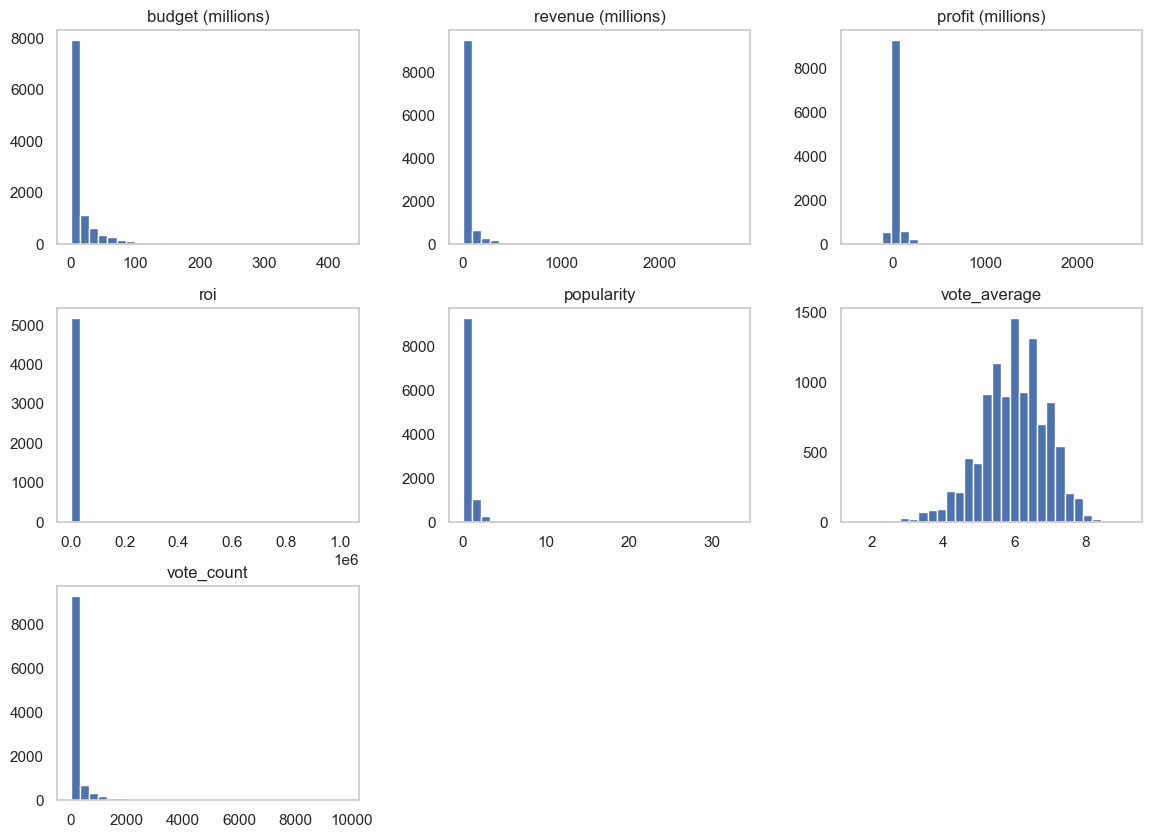

In [26]:
movies_hist = movies_cleaned[['budget (millions)', 'revenue (millions)', 'profit (millions)', 'roi', 'popularity', 'vote_average', 'vote_count']]
movies_hist.hist(bins = 30, figsize = (14, 10), grid = False)
plt.show()

# Popularity is not normally distributed, it is right skewed. 
# Let's just focus on movies with popularity below the 99th percentile to see if there are any interesting insights we can gain from them.

In [27]:
movies_hist['popularity'].value_counts() 

popularity
0.14    193
0.28    190
0.21    186
0.25    182
0.32    179
       ... 
5.74      1
4.97      1
1.99      1
3.07      1
2.68      1
Name: count, Length: 483, dtype: int64

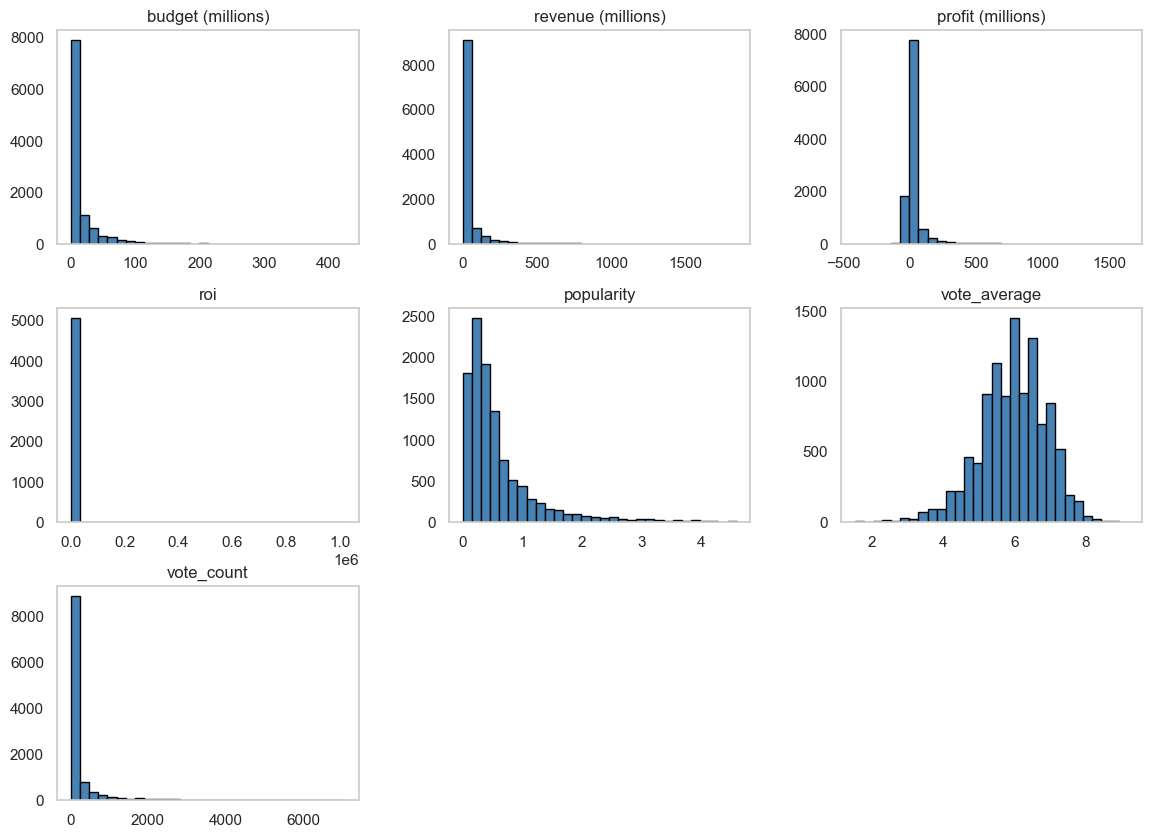

In [28]:
p99 = movies_hist['popularity'].quantile(0.99) # 99th percentile of the popularity column
filtered_movies = movies_hist[movies_hist['popularity'] < p99] # filter the movies with popularity less than 99th percentile
filtered_movies.hist(bins = 30, figsize = (14, 10), color = 'steelblue', edgecolor = 'black', grid = False)
plt.show()

In [29]:
# let's now look at the distribution of the revenue (millions) column
movies_cleaned['revenue (millions)'].value_counts()

revenue (millions)
0.00       6021
0.01         43
0.02         21
0.03         16
0.05         15
           ... 
183.99        1
36.87         1
243.64        1
1405.04       1
155.76        1
Name: count, Length: 3664, dtype: int64

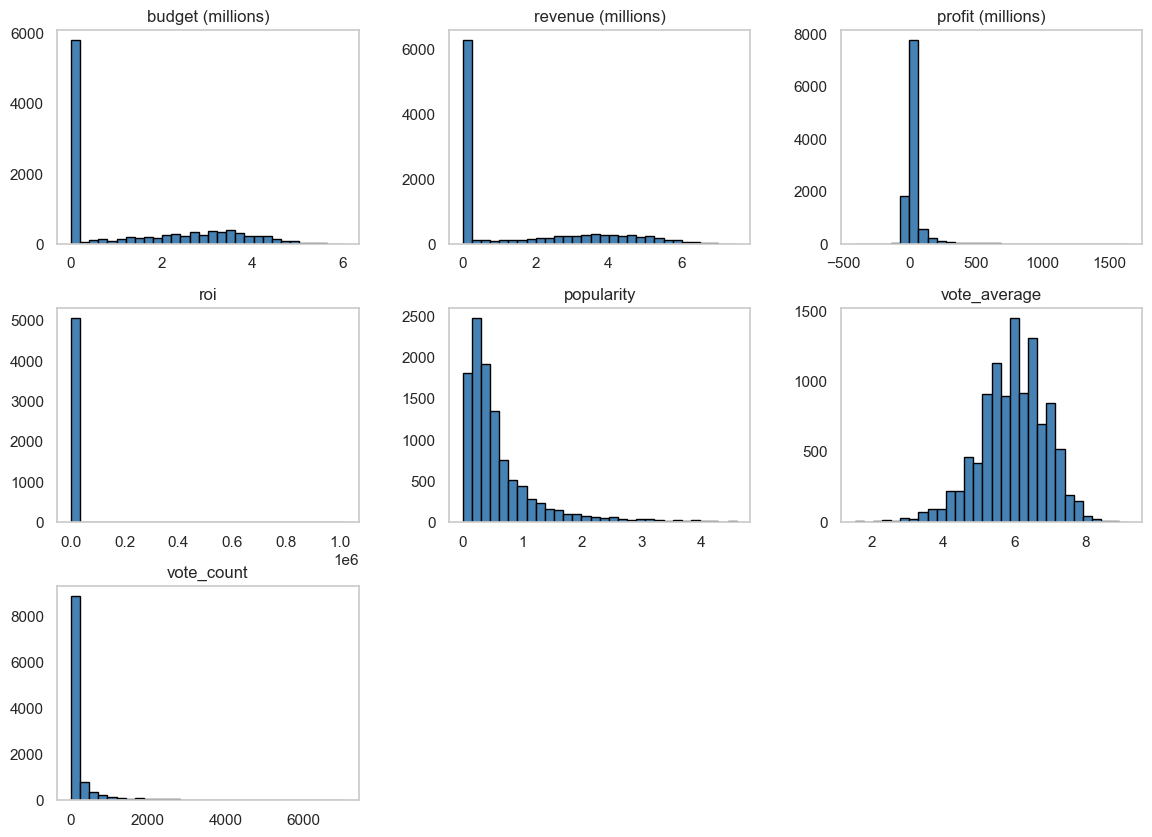

In [30]:
# transform the revenue (millions) column and budget (millions) using log transformation to make it more normally distributed
filtered_movies = filtered_movies.copy()

filtered_movies[['budget (millions)', 'revenue (millions)']] = np.log1p(filtered_movies[['budget (millions)', 'revenue (millions)']]) # log transformation of budget and revenue columns

filtered_movies.hist(bins = 30, figsize = (14, 10), color = 'steelblue', edgecolor = 'black', grid = False)
plt.show();

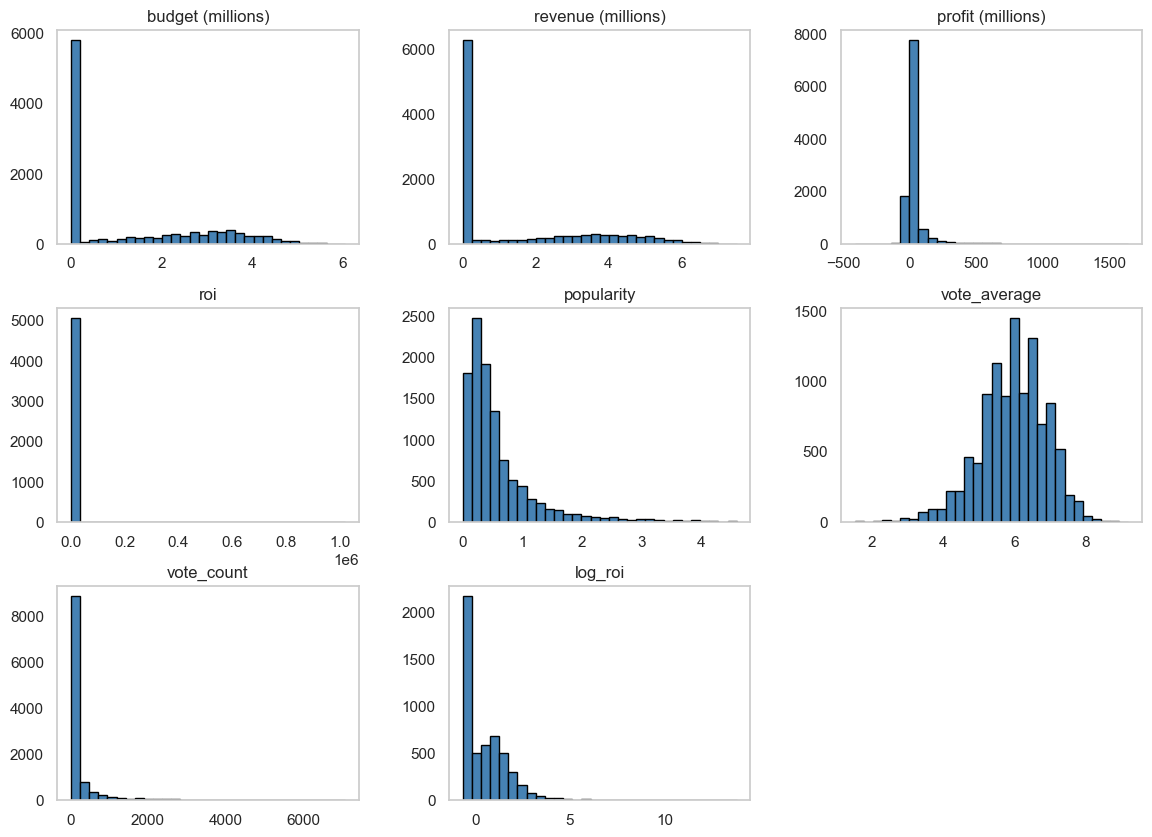

In [31]:
# transform the roi column to make it more normally distributed
filtered_movies['log_roi'] = np.sign(filtered_movies['roi']) * np.log1p(np.abs(filtered_movies['roi'])) # log transformation of roi column to compresses extreme values while preserving whether the ROI is positive or negative.
filtered_movies.hist(bins = 30, figsize = (14, 10), color = 'steelblue', edgecolor = 'black', grid = False)
plt.show();

The distributions show that most financial and engagement-related variables are strongly right-skewed. Budget, revenue, profit, popularity and vote count contain a relatively small number of movies with exceptionally high values, while most observations occur toward the lower end of their respective distributions. Vote average is comparatively symmetric and concentrated around ratings of approximately 5–7. Raw ROI is extremely right-skewed due to several exceptionally large values, while the signed-log transformation produces a substantially more interpretable distribution. The large concentration of zero values in budget and revenue should be investigated to determine whether these represent genuine values or missing/unreported data.

### 5.2 Correlation between Variables 

Here, we look at the correlation between key variables such as `budget (millions)`, `revenue (millions)`, `profit (millions)`, `roi` `popularity`, `vote_average`, `vote_count`, `release_year`.

In [32]:
corr_columns = [
    "budget (millions)",
    "revenue (millions)",
    "profit (millions)",
    "roi",
    "popularity",
    "vote_average",
    "vote_count",
    "release_year"
]

corr_matrix = movies_cleaned[corr_columns].corr()

corr_matrix

,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count,release_year
budget (millions),1.000000,0.734712,0.569981,-0.012221,0.544854,0.083637,0.632390,0.117442
revenue (millions),0.734712,1.000000,0.976167,0.002851,0.663075,0.175030,0.791028,0.058090
profit (millions),0.569981,0.976167,1.000000,0.006883,0.628819,0.185241,0.755792,0.032788
roi,-0.012221,0.002851,0.006883,1.000000,-0.002909,-0.003754,-0.003878,-0.018882
popularity,0.544854,0.663075,0.628819,-0.002909,1.000000,0.213061,0.800691,0.091340
vote_average,0.083637,0.175030,0.185241,-0.003754,0.213061,1.000000,0.256772,-0.122493
vote_count,0.632390,0.791028,0.755792,-0.003878,0.800691,0.256772,1.000000,0.109144
release_year,0.117442,0.058090,0.032788,-0.018882,0.091340,-0.122493,0.109144,1.000000


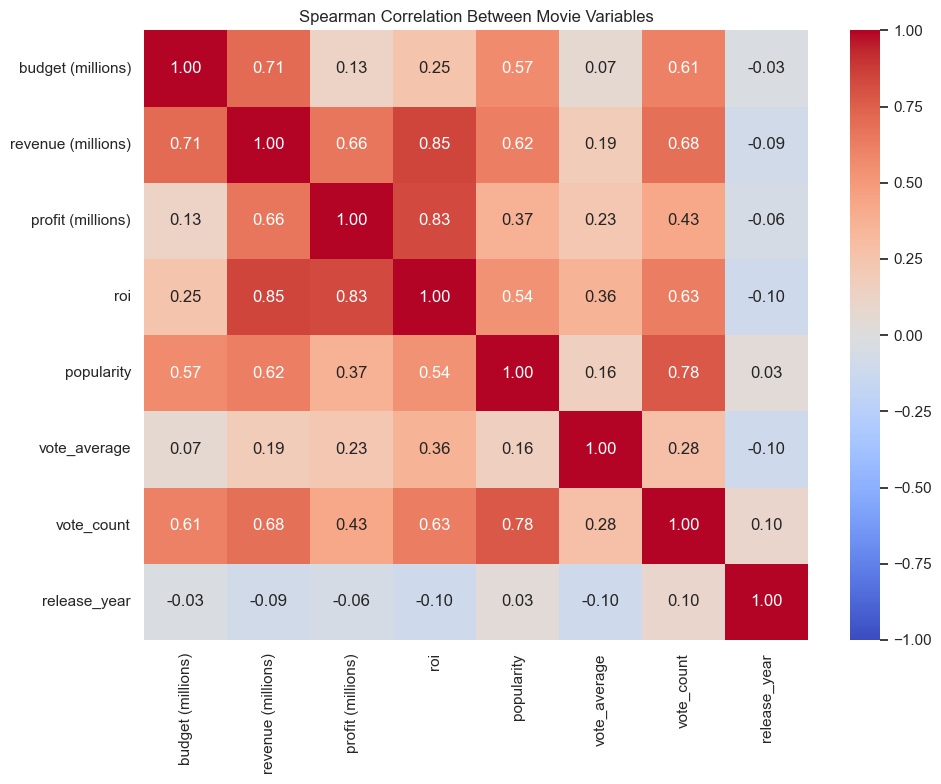

In [33]:
spearman_corr = movies_cleaned[corr_columns].corr(method="spearman")

plt.figure(figsize=(10, 8))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Spearman Correlation Between Movie Variables")
plt.tight_layout()
plt.show()

Spearman correlation analysis revealed several notable associations between movie characteristics and performance. Budget showed a strong positive correlation with revenue (ρ = 0.71), suggesting that higher-budget films generally generated greater revenue. However, the relationship between budget and profit was weak (ρ = 0.13), indicating that greater production expenditure does not necessarily translate into greater profitability. Popularity was strongly correlated with vote count (ρ = 0.78), suggesting that more popular films generally attracted greater audience engagement. In contrast, average user rating showed only weak relationships with most financial variables, including revenue (ρ = 0.19) and profit (ρ = 0.23). Release year also showed little association with the performance variables. Correlations involving revenue, profit and ROI should be interpreted cautiously because profit and ROI are mathematically derived from revenue and budget.

## 6. Main Analysis
### 6.1 Financial Performance Analysis

In this section, we aim to find out which are the most financially successful films. 

We will do so by looking at films that made the most profit, the relationship between budget and profit, budget and revenue and lastly budget and log_roi. 
We will then analyse the genres that made the highest average roi to determine the relationship between movie genre and roi.
Lastly, we will conclude with a plot of the top 5 most financially successful films. 

#### 6.1.1 Most Profitable Movies

In [34]:
# let's find the top 5 most profitable movies in the dataset
most_profitable_movies = movies_cleaned.sort_values(by = 'profit (millions)', ascending = False)
most_profitable_movies.head(5)

# 'Avatar' made the most profit, followed by 'Star Wars: The Force Awakens', 'Titanic', 'Jurassic World' and 'Furious 7'.

,original_title,release_year,director,production_companies,genres,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count
1386,Avatar,2009,James Cameron,Ingenious Film Partners|Twentieth Century Fox ...,Action|Adventure|Fantasy|Science Fiction,237.0,2781.51,2544.51,10.74,9.43,7.1,8458
3,Star Wars: The Force Awakens,2015,J.J. Abrams,Lucasfilm|Truenorth Productions|Bad Robot,Action|Adventure|Science Fiction|Fantasy,200.0,2068.18,1868.18,9.34,11.17,7.5,5292
5231,Titanic,1997,James Cameron,Paramount Pictures|Twentieth Century Fox Film ...,Drama|Romance|Thriller,200.0,1845.03,1645.03,8.23,4.36,7.3,4654
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,Action|Adventure|Science Fiction|Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
4,Furious 7,2015,James Wan,Universal Pictures|Original Film|Media Rights ...,Action|Crime|Thriller,190.0,1506.25,1316.25,6.93,9.34,7.3,2947


In [35]:
average_profit = movies_cleaned['profit (millions)'].mean()
average_profit # the mean profit of all the movies in the dataset is 25.4 million dollars

np.float64(25.35443767694445)

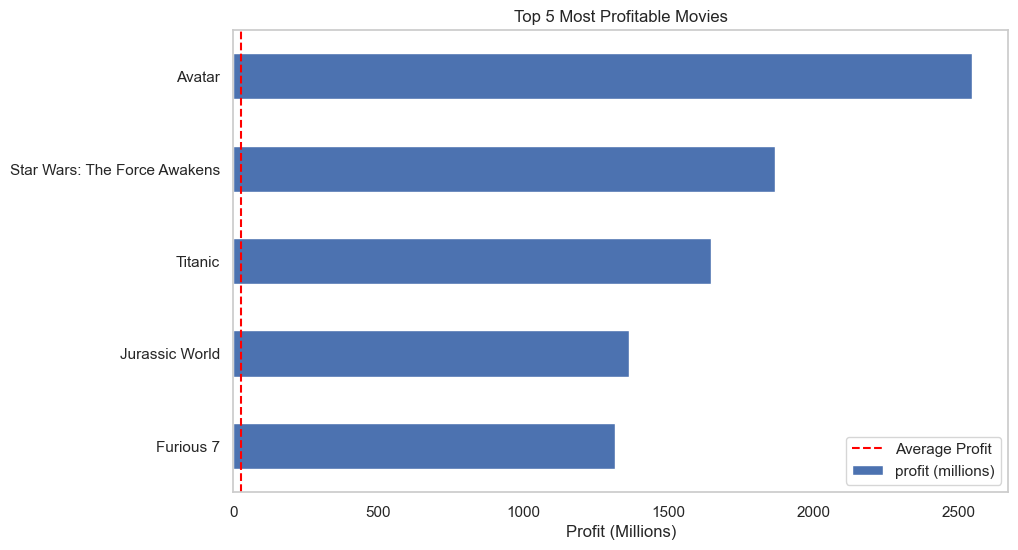

In [36]:
# let's visualise the top 5 most profitable movies
most_profitable_movies.head(5).sort_values(by = 'profit (millions)', ascending = True).plot.barh(x='original_title', y='profit (millions)', grid = False, figsize = (10,6))
plt.axvline(x=average_profit, color='red', linestyle='--', label='Average Profit')
plt.xlabel('Profit (Millions)')
plt.ylabel('')
plt.title('Top 5 Most Profitable Movies')
plt.legend()
plt.show()

In [37]:
fig = px.box(
    movies_cleaned,
    y = "profit (millions)",
    points = "outliers",              # show every movie as a point
    hover_name = "original_title",        
    hover_data={
        "profit (millions)": ":.1f"
    },
    title = "Distribution of Movie Profits"
)

fig.update_traces(
    jitter=0.3,
    pointpos=0,
    marker=dict(
        size=5,
        opacity=0.7
    )
)

fig.update_layout(
    xaxis_title = None,
    yaxis_title = "Profit (millions)",
    template = "seaborn",
    height = 600
)

fig.update_xaxes(
    showticklabels=False,
    showgrid=False
)

fig.show()

#### 6.1.2 Relationship between Budget and Key Financial Performance Metrics (Profit, Revenue, Return on Investment)

In this section, we check whether there is a definitive relationship between `budget (millions)` and `revenue (millions)` or `profit (millions)` or `roi`.  

Text(0, 0.5, 'Profit (Millions)')

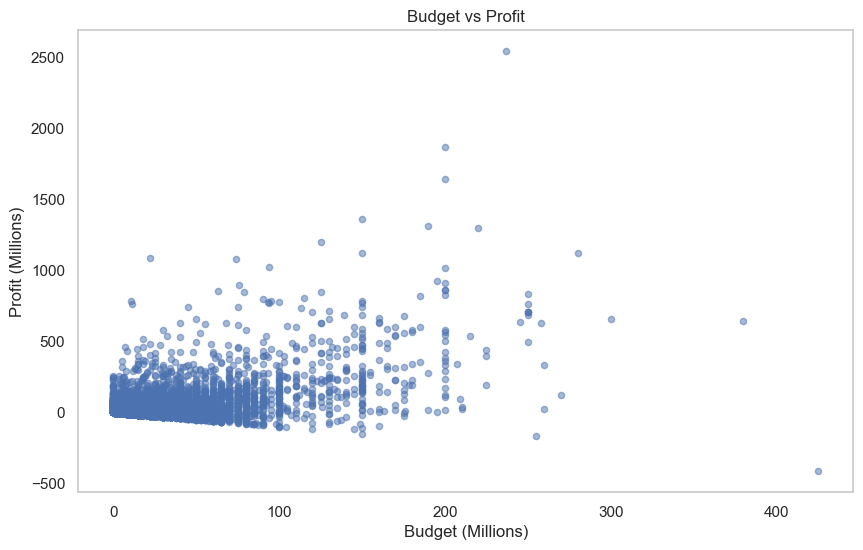

In [38]:
# let's first look at budget vs profit  
movies_cleaned.plot(kind='scatter', x='budget (millions)', y='profit (millions)', alpha=0.5, figsize=(10, 6), grid = False)
plt.title('Budget vs Profit')
plt.xlabel('Budget (Millions)')
plt.ylabel('Profit (Millions)')

The scatterplot shows a weak positive relationship between movie budget and profit. Although higher-budget films have the potential to generate substantially greater profits, profitability becomes increasingly variable as budget rises. Several high-budget films achieved exceptional profits, while others generated only modest returns or losses. This suggests that a larger production budget does not necessarily translate into greater profitability.

Text(0, 0.5, 'Revenue (Millions)')

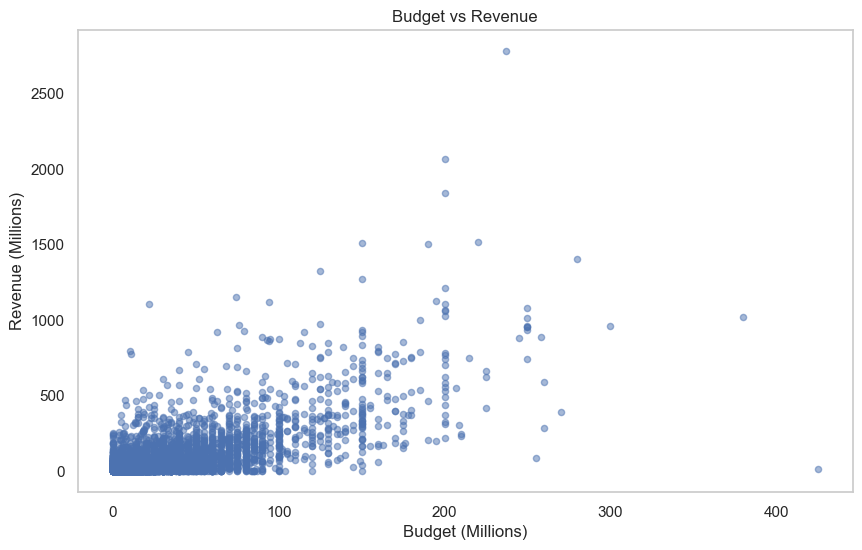

In [39]:
# next, let's look at budget vs revenue 
movies_cleaned.plot(kind='scatter', x='budget (millions)', y='revenue (millions)', alpha=0.5, figsize=(10, 6), grid = False)
plt.title('Budget vs Revenue')
plt.xlabel('Budget (Millions)')
plt.ylabel('Revenue (Millions)')

Visually, budget–revenue and budget–profit show similar highly dispersed patterns. However, the Spearman correlations reveal an important distinction: budget has a relatively strong positive monotonic association with revenue (ρ = 0.71), but only a weak association with profit (ρ = 0.13). This suggests that larger-budget films generally earn more revenue, but the additional revenue does not consistently translate into greater profit because higher-budget films also incur greater production costs.

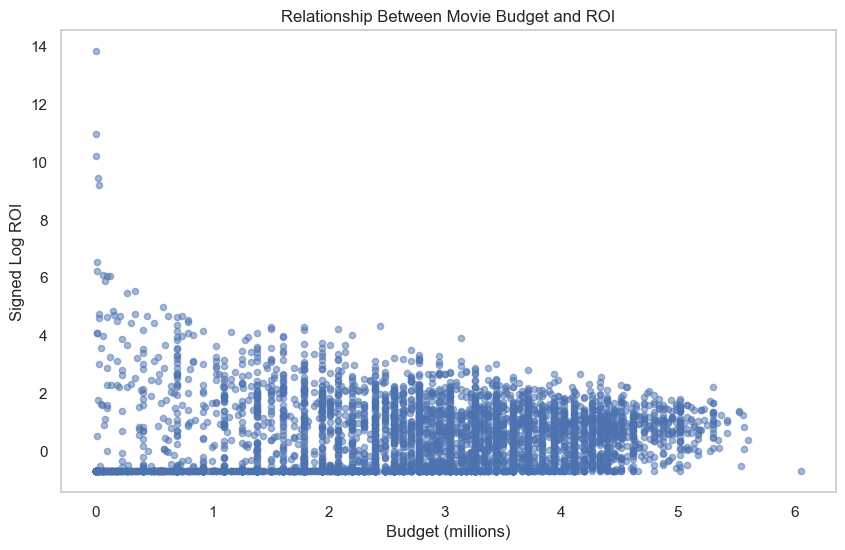

In [40]:
filtered_movies.plot(kind="scatter", x="budget (millions)", y="log_roi", alpha=0.5,figsize=(10, 6), grid = False)

plt.title("Relationship Between Movie Budget and ROI")
plt.xlabel("Budget (millions)")
plt.ylabel("Signed Log ROI")
plt.show()

The scatterplot shows that ROI variability decreases as movie budget increases. Low-budget films display a very wide range of returns, including several exceptionally high ROI values, whereas higher-budget films are concentrated within a narrower range of more moderate returns. This suggests that lower-budget films may have greater relative upside but also highly variable outcomes. The relationship is therefore better characterised by changing variability in ROI across budget levels rather than by a simple strong negative correlation.

#### 6.1.3 Genres that Made the Highest Average Return on Investment

In this section, we investigate which genres are the most financially successful by comparing each genre's roi. 

In [41]:
movies_genres = movies_cleaned.copy()

split = ['genres']
for i in split:
    movies_genres[i] = movies_cleaned[i].apply(lambda x: x.split('|')) # split the genres column into a list of genres

movies_genres.head(3)

,original_title,release_year,director,production_companies,genres,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,"[Action, Adventure, Science Fiction, Thriller]",150.0,1513.53,1363.53,9.09,32.99,6.5,5562
1,Mad Max: Fury Road,2015,George Miller,Village Roadshow Pictures|Kennedy Miller Produ...,"[Action, Adventure, Science Fiction, Thriller]",150.0,378.44,228.44,1.52,28.42,7.1,6185
2,Insurgent,2015,Robert Schwentke,Summit Entertainment|Mandeville Films|Red Wago...,"[Adventure, Science Fiction, Thriller]",110.0,295.24,185.24,1.68,13.11,6.3,2480


In [42]:
movies_genres_exploded = movies_genres.explode('genres') # explode the genres column to create a new row for each genre
movies_genres_exploded.head()

,original_title,release_year,director,production_companies,genres,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,Action,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,Adventure,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,Science Fiction,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
1,Mad Max: Fury Road,2015,George Miller,Village Roadshow Pictures|Kennedy Miller Produ...,Action,150.0,378.44,228.44,1.52,28.42,7.1,6185


In [43]:
movies_genres_exploded_transformed = np.sign(movies_genres_exploded['roi']) * np.log1p(np.abs(movies_genres_exploded['roi'])) 

In [44]:
genre_roi = movies_genres_exploded.copy()

genre_roi["log_roi"] = (
    np.sign(genre_roi["roi"]) *
    np.log1p(np.abs(genre_roi["roi"]))
)

genre_roi = genre_roi.dropna(subset=["genres", "log_roi"])

fig = px.box(
    genre_roi,
    x="genres",
    y="log_roi",
    hover_name="original_title",
    hover_data={
        "genres": True,
        "log_roi": ":.2f"
    },
    points="outliers",
    title="Relationship Between Movie Genre and ROI",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Genres",
    yaxis_title="Signed Log ROI"
)

fig.show()

The distribution of ROI varies across movie genres, although substantial overlap exists between most genres. Family, Animation and Adventure appear to exhibit relatively higher median returns, while several genres show lower median ROI. However, the overlapping interquartile ranges suggest that genre alone may not strongly determine profitability. Several genres also contain extreme positive ROI outliers, indicating that exceptionally successful films can occur across different genres. Results for genres with relatively few observations should be interpreted cautiously.

#### 6.1.4 Top 5 Most Financially Successful Films 

In [45]:
top_5_roi = (
    movies_cleaned
    .sort_values("roi", ascending=False)
    .head(5)
)

In [46]:
top_5_profit = (
    movies_cleaned
    .sort_values("profit (millions)", ascending=False)
    .head(5)
)

In [47]:
# Top 5 films by ROI
top_5_roi = (
    movies_cleaned
    .sort_values("roi", ascending=False)
    .head(5)
    .sort_values("roi", ascending=True)
)

# Top 5 films by profit
top_5_profit = (
    movies_cleaned
    .sort_values("profit (millions)", ascending=False)
    .head(5)
    .sort_values("profit (millions)", ascending=True)
)

# Create two side-by-side plots
fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.25,
    subplot_titles=("Top 5 Films by ROI", "Top 5 Films by Profit")
)

# ROI chart
fig.add_trace(
    go.Bar(
        x=top_5_roi["roi"],
        y=top_5_roi["original_title"],
        orientation="h",
        marker_color="steelblue",
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "ROI: %{x:.2f}<extra></extra>"
        )
    ),
    row=1,
    col=1
)

# Profit chart
fig.add_trace(
    go.Bar(
        x=top_5_profit["profit (millions)"],
        y=top_5_profit["original_title"],
        orientation="h",
        marker_color="darkorange",
        textposition="outside",

        hovertemplate=(
            "<b>%{y}</b><br>"
            "Profit: $%{x:.2f} million<extra></extra>"
        )
    ),
    row=1,
    col=2
)

fig.update_xaxes(title_text="ROI", row=1, col=1)
fig.update_xaxes(
    title_text="Profit (millions)",
    row=1,
    col=2
)

fig.update_yaxes(title_text="Film", row=1, col=1)
fig.update_yaxes(title_text="", row=1, col=2)

fig.update_layout(
    title="Most Financially Successful Films",
    template="plotly_white",
    showlegend=False,
    height=550,
    width=1100
)

fig.show()

In [48]:
# check why there was an exceptionally high ROI recorded for Karate Kid, Part II
movies_cleaned.loc[
    movies_cleaned["original_title"] == "The Karate Kid, Part II",
    ["original_title", "budget (millions)", "revenue (millions)",
     "profit (millions)", "roi"]
]

,original_title,budget (millions),revenue (millions),profit (millions),roi
10495,"The Karate Kid, Part II",0.000113,115.1,115.099887,1018583.07


The ranking demonstrates that financial success differs depending on whether it is measured using absolute profit or return on investment. High-profit films such as Avatar and Star Wars: The Force Awakens generated the greatest absolute financial gains, whereas the highest-ROI films tended to achieve large returns relative to comparatively small production budgets. The substantial difference between the two rankings indicates that the most profitable films are not necessarily the most efficient investments.

### 6.2 Popularity Analysis 


In this section, we look at which are the most popular films. 

We also investigate which genre, production company and film director is the most popular.

#### 6.2.1 Top 5 Most Popular Films 


In [49]:
movies_top5_popular = movies_cleaned.sort_values(by = 'popularity', ascending = False).head(5)
movies_top5_popular

,original_title,release_year,director,production_companies,genres,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count
0,Jurassic World,2015,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,Action|Adventure|Science Fiction|Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
1,Mad Max: Fury Road,2015,George Miller,Village Roadshow Pictures|Kennedy Miller Produ...,Action|Adventure|Science Fiction|Thriller,150.0,378.44,228.44,1.52,28.42,7.1,6185
629,Interstellar,2014,Christopher Nolan,Paramount Pictures|Legendary Pictures|Warner B...,Adventure|Drama|Science Fiction,165.0,621.75,456.75,2.77,24.95,8.0,6498
630,Guardians of the Galaxy,2014,James Gunn,Marvel Studios|Moving Picture Company (MPC)|Bu...,Action|Science Fiction|Adventure,170.0,773.31,603.31,3.55,14.31,7.9,5612
2,Insurgent,2015,Robert Schwentke,Summit Entertainment|Mandeville Films|Red Wago...,Adventure|Science Fiction|Thriller,110.0,295.24,185.24,1.68,13.11,6.3,2480


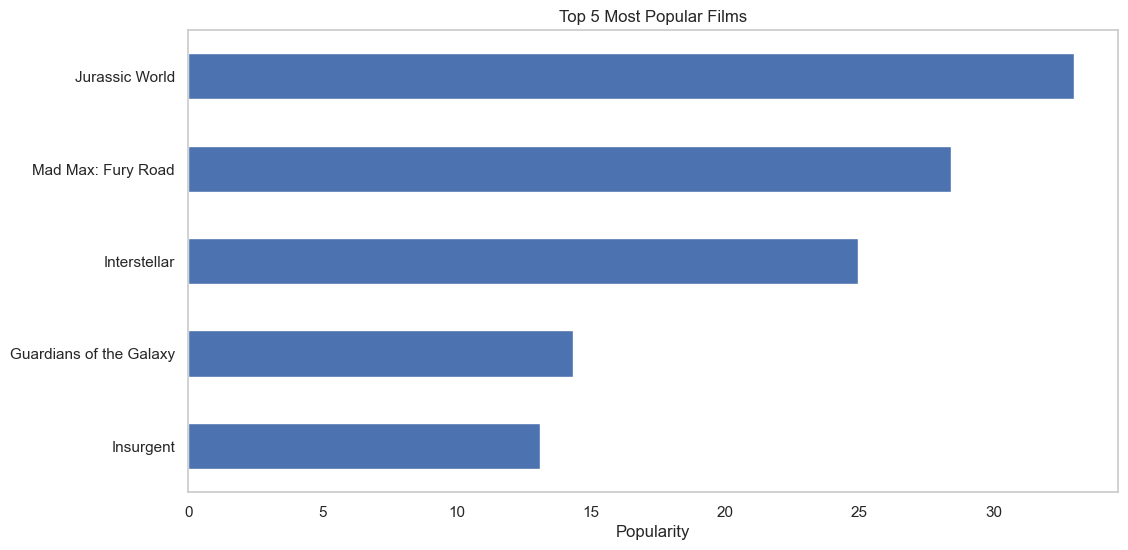

In [50]:
movies_top5_popular.sort_values(by='popularity', ascending=True).plot.barh(x = 'original_title', y = 'popularity', grid = False, figsize = (12,6))
plt.title('Top 5 Most Popular Films')
plt.xlabel('Popularity')
plt.ylabel('')
plt.legend().remove()

#### 6.2.2 Total Popularity by Genre

We investigate which genre is the most popular. 

In [51]:
movies_genres = movies_genres_exploded.groupby('genres')['popularity'].sum().sort_values(ascending = True) # group the movies by genres and calculate the sum of popularity for each genre
movies_genres

genres
Foreign              35.24
TV Movie             44.03
Documentary          93.13
Western              97.42
History             192.35
War                 196.48
Music               198.15
Mystery             558.55
Animation           594.46
Horror              761.39
Fantasy             908.87
Family              967.06
Crime              1008.47
Romance            1013.21
Science Fiction    1229.81
Adventure          1697.11
Thriller           2155.30
Action             2207.48
Comedy             2246.25
Drama              2814.83
Name: popularity, dtype: float64

Text(0.5, 0, 'Popularity')

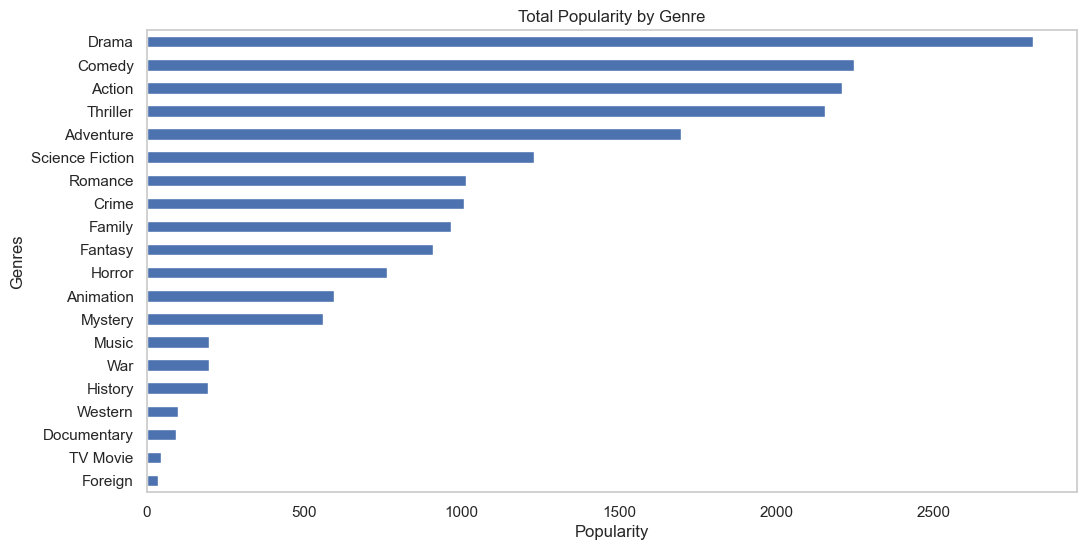

In [52]:
movies_genres.plot.barh(x = 'genres', y = 'popularity', figsize = (12, 6), grid = False)
plt.title('Total Popularity by Genre')
plt.ylabel('Genres')
plt.xlabel('Popularity')

#### 6.2.3 Total Popularity by Production Company 

We investigate which are the most popular production companies. 

In [53]:
split2 = ['production_companies']
movies_production_company = movies_cleaned.copy()
for i in split2:
    movies_production_company[i] = movies_production_company[i].apply(lambda x: x.split('|')) # split the production companies column into a list of production companies

movies_production_company.head(3)

,original_title,release_year,director,production_companies,genres,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count
0,Jurassic World,2015,Colin Trevorrow,"[Universal Studios, Amblin Entertainment, Lege...",Action|Adventure|Science Fiction|Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
1,Mad Max: Fury Road,2015,George Miller,"[Village Roadshow Pictures, Kennedy Miller Pro...",Action|Adventure|Science Fiction|Thriller,150.0,378.44,228.44,1.52,28.42,7.1,6185
2,Insurgent,2015,Robert Schwentke,"[Summit Entertainment, Mandeville Films, Red W...",Adventure|Science Fiction|Thriller,110.0,295.24,185.24,1.68,13.11,6.3,2480


In [54]:
movies_production_company_exploded = movies_production_company.explode('production_companies') # explode the production companies column to create a new row for each production company
movies_production_company_exploded.head(3)

,original_title,release_year,director,production_companies,genres,budget (millions),revenue (millions),profit (millions),roi,popularity,vote_average,vote_count
0,Jurassic World,2015,Colin Trevorrow,Universal Studios,Action|Adventure|Science Fiction|Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
0,Jurassic World,2015,Colin Trevorrow,Amblin Entertainment,Action|Adventure|Science Fiction|Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562
0,Jurassic World,2015,Colin Trevorrow,Legendary Pictures,Action|Adventure|Science Fiction|Thriller,150.0,1513.53,1363.53,9.09,32.99,6.5,5562


In [55]:
movies_production_company_exploded = movies_production_company_exploded[movies_production_company_exploded['production_companies'] != 'Unknown'] # filter the movies that have production companies

In [56]:
movies_production_companies_grouped = movies_production_company_exploded.groupby('production_companies')['popularity'].sum().sort_values(ascending = False) # group the movies by production companies and calculate the sum of popularity for each company
movies_production_companies_grouped.count() # check for the number of production companies in the grouped data

np.int64(7863)

In [57]:
production_companies_top_10 = movies_production_companies_grouped.head(10) # get the top 10 production companies by popularity
production_companies_top_10

production_companies
Warner Bros.                              590.87
Universal Pictures                        499.95
Paramount Pictures                        418.32
Twentieth Century Fox Film Corporation    345.77
Walt Disney Pictures                      295.64
Columbia Pictures                         285.19
New Line Cinema                           240.26
Metro-Goldwyn-Mayer (MGM)                 180.31
Village Roadshow Pictures                 156.03
Legendary Pictures                        154.76
Name: popularity, dtype: float64

Text(0.5, 0, 'Popularity')

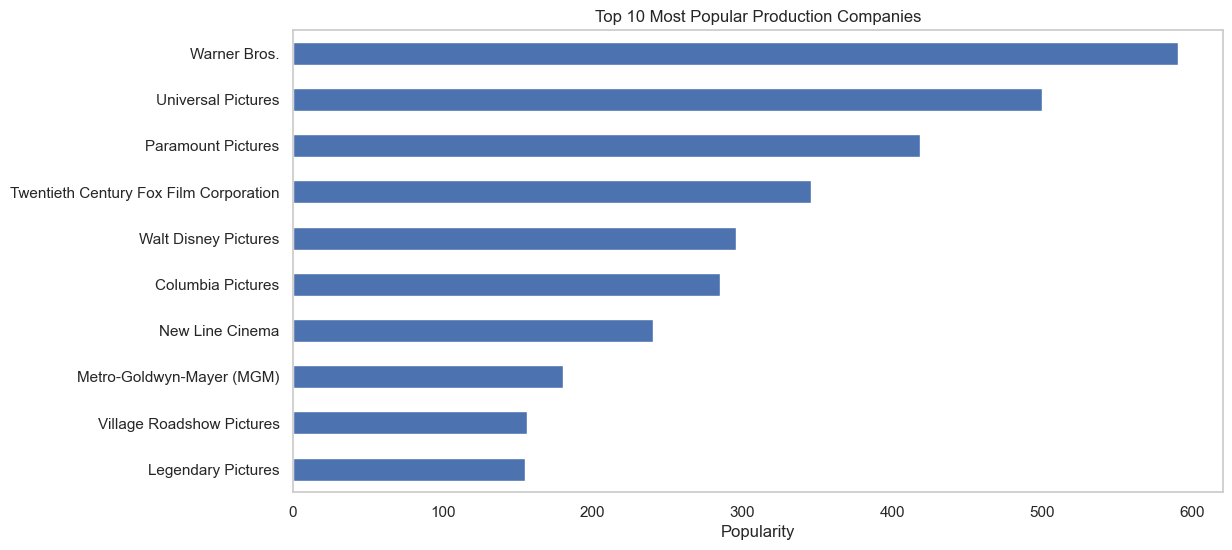

In [58]:
production_companies_top_10 = production_companies_top_10.sort_values(ascending=True)
production_companies_top_10.plot.barh(x = 'production_companies', y = 'popularity', figsize = (12, 6), grid = False)
plt.title("Top 10 Most Popular Production Companies")
plt.ylabel('')
plt.xlabel('Popularity')

#### 6.2.4 Total Popularity by Movie Director

We investigate which are the most popular movie directors. 

In [59]:
movies_director = movies_cleaned.groupby('director')['popularity'].sum().sort_values(ascending=False)
movies_director

director
Christopher Nolan            61.96
Steven Spielberg             54.35
Peter Jackson                49.07
Ridley Scott                 46.23
Quentin Tarantino            46.06
                             ...  
David Higby                   0.00
James Erskine                 0.00
Madhur Bhandarkar             0.00
Zana Briski|Ross Kauffman     0.00
Zak Levitt                    0.00
Name: popularity, Length: 5056, dtype: float64

In [60]:
movies_director_top10 = movies_director.head(10)
movies_director_top10

director
Christopher Nolan    61.96
Steven Spielberg     54.35
Peter Jackson        49.07
Ridley Scott         46.23
Quentin Tarantino    46.06
George Miller        35.59
Tim Burton           34.66
David Fincher        34.48
Robert Zemeckis      33.62
Colin Trevorrow      33.40
Name: popularity, dtype: float64

Text(0, 0.5, '')

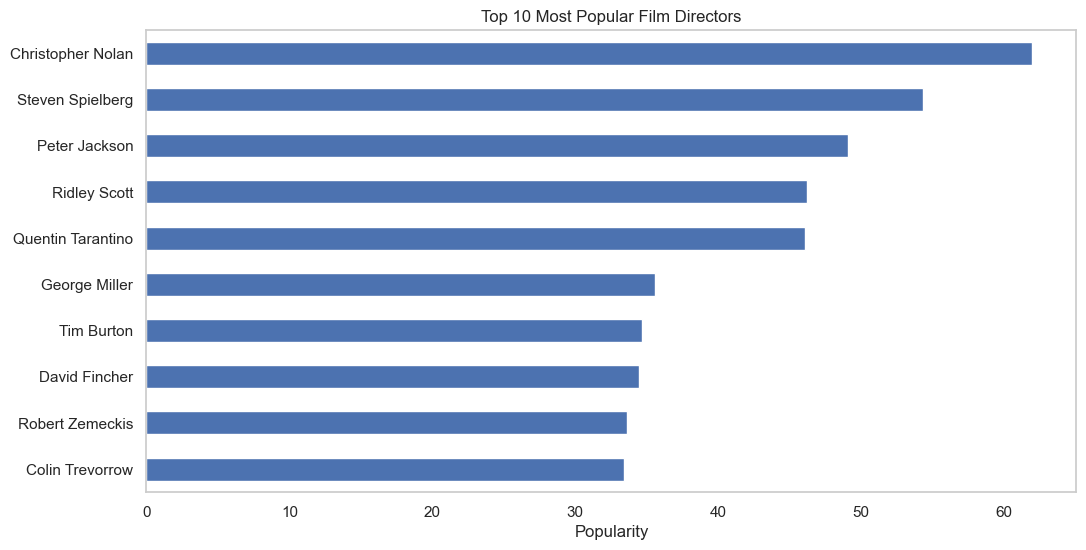

In [61]:
movies_director_top10.sort_values(ascending=True).plot.barh(x = 'popularity', y = 'director', grid = False, figsize = (12, 6))
plt.title('Top 10 Most Popular Film Directors')
plt.xlabel('Popularity')
plt.ylabel('')

### 6.3 Movie Trends Over Time
In this section, we investigate how movie trends are changing over time. In particular, we look at how movies financial performance (budget, revenue and profit) change and how movie consumer preferences (genre) change over time. 

#### 6.3.1 Movie Performance Over Time 

In [62]:
# Calculate yearly averages
yearly_financials = (
    movies_cleaned
    .groupby("release_year", as_index=False)
    .agg(
        average_budget=("budget (millions)", "mean"),
        average_revenue=("revenue (millions)", "mean"),
        average_profit=("profit (millions)", "mean")
    )
    .sort_values("release_year")
)

# Create the line graph
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=yearly_financials["release_year"],
    y=yearly_financials["average_budget"],
    mode="lines+markers",
    name="Average Budget",
    line=dict(color="royalblue", width=2)
))

fig.add_trace(go.Scatter(
    x=yearly_financials["release_year"],
    y=yearly_financials["average_revenue"],
    mode="lines+markers",
    name="Average Revenue",
    line=dict(color="seagreen", width=2)
))

fig.add_trace(go.Scatter(
    x=yearly_financials["release_year"],
    y=yearly_financials["average_profit"],
    mode="lines+markers",
    name="Average Profit",
    line=dict(color="darkorange", width=2)
))

fig.update_layout(
    title="Average Budget, Revenue and Profit Over Time",
    xaxis_title="Release Year",
    yaxis_title="Amount (millions)",
    template="plotly_white",
    hovermode="x unified",
    height=550,
    width=1100
)

fig.show()

Average movie budgets, revenues and profits generally increased from the 1960s through the 1990s and early 2000s. Revenue increased more substantially than production budget, resulting in higher average profits during the later decades of the dataset. Average revenue reached its highest levels around the late 1990s and early 2000s, after which both revenue and budget showed some decline. Considerable year-to-year variation is present, particularly in earlier years, which may partly reflect differences in the number of films represented and the influence of exceptionally successful movies. As the monetary values are not adjusted for inflation, long-term comparisons should also be interpreted cautiously.

#### 6.3.2 Movie Preferance Over Time

In [65]:
# Prepare genre data
genre_data = movies_cleaned.copy()
genre_data["genres"] = genre_data["genres"].str.split("|")
genre_data = genre_data.explode("genres")

# Find the 8 genres with the highest overall average popularity
top_genres = (
    genre_data.groupby("genres")["popularity"]
    .mean()
    .nlargest(5)
    .index
)

genre_data = genre_data[genre_data["genres"].isin(top_genres)]

# Calculate average popularity by year and genre
genre_popularity = (
    genre_data
    .groupby(["release_year", "genres"], as_index=False)["popularity"]
    .mean()
    .sort_values(["genres", "release_year"])
)

# Smooth the yearly fluctuations using a 3-year rolling average
genre_popularity["rolling_popularity"] = (
    genre_popularity
    .groupby("genres")["popularity"]
    .transform(lambda values: values.rolling(3, min_periods=1).mean())
)

# Plot the cleaner chart
fig = px.line(
    genre_popularity,
    x="release_year",
    y="rolling_popularity",
    color="genres",
    title="Popularity Trends for the Most Popular Genres",
    labels={
        "rolling_popularity": "Three-Year Average Popularity",
        "genres": "Genre",
        "release_year": "Year"
    },
    hover_data={
        "rolling_popularity": ":.2f"
    }
)

fig.update_traces(
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Three-Year Average Popularity: %{y:.2f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=600,
    hovermode="x unified",
    legend_title="Genre"
)

fig.show()